<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance

**Analyze Big Financial Data**

O'Reilly (2014)

Yves Hilpisch

<img style="border:0px solid grey;" src="http://hilpisch.com/python_for_finance.png" alt="Python for Finance" width="30%" align="left" border="0">

**Buy the book ** |
<a href='http://shop.oreilly.com/product/0636920032441.do' target='_blank'>O'Reilly</a> |
<a href='http://www.amazon.com/Yves-Hilpisch/e/B00JCYHHJM' target='_blank'>Amazon</a>

**All book codes & IPYNBs** |
<a href="http://oreilly.quant-platform.com">http://oreilly.quant-platform.com</a>

**The Python Quants GmbH** | <a href='http://tpq.io' target='_blank'>http://tpq.io</a>

**Contact us** | <a href='mailto:pff@tpq.io'>pff@tpq.io</a>

## Introduction

In [4]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

## Finance and Python Syntax

In [5]:
S0 = 100.
K = 105.
T = 1.0
r = 0.05
sigma = 0.2

In [ ]:
from numpy import *
import numpy as np

I = 100000

np.random.seed(1000)
z = np.random.standard_normal(I)
ST = S0 * np.exp(r * T + sigma * np.sqrt(T) * z)
hT = np.maximum(ST - K, 0)
C0 = np.exp(-r * T) * np.sum(hT) / I

In [7]:
print("Value of the European Call Option %5.3f" % C0)

Value of the European Call Option 9.149


## Time-to-Results

In [9]:
import numpy as np
import pandas as pd

In [1]:
pwd

'd:\\F financial data analysis\\Lecture materials\\Chapter1 code'

In [ ]:
# data from Thomson Reuters Eikon API
raw = pd.read_csv('tr_eikon_eod_data.csv',
                   index_col=0, parse_dates=True)

In [11]:
raw

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82
2010-01-08,30.282827,30.660,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.10,49.84,111.37
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-10-25,156.410000,78.630,40.78,972.91,241.71,255.29,2557.15,11.23,1.1812,1277.01,22.83,121.35
2017-10-26,157.410000,78.760,41.35,972.43,241.72,255.62,2560.40,11.30,1.1650,1266.73,22.43,120.33
2017-10-27,163.050000,83.810,44.40,1100.95,241.71,257.71,2581.07,9.80,1.1608,1272.60,22.57,120.90


In [12]:
type(raw)

pandas.core.frame.DataFrame

In [13]:
raw['AMZN.O']

Date
2010-01-04     133.90
2010-01-05     134.69
2010-01-06     132.25
2010-01-07     130.00
2010-01-08     133.52
               ...   
2017-10-25     972.91
2017-10-26     972.43
2017-10-27    1100.95
2017-10-30    1110.85
2017-10-31    1105.28
Name: AMZN.O, Length: 1972, dtype: float64

In [14]:
amzn = pd.DataFrame(raw['AMZN.O'])
amzn.columns = ['Close']
amzn.tail()

,Close
Date,
2017-10-25,972.91
2017-10-26,972.43
2017-10-27,1100.95
2017-10-30,1110.85
2017-10-31,1105.28


In [15]:
amzn['Close'].head()

Date
2010-01-04    133.90
2010-01-05    134.69
2010-01-06    132.25
2010-01-07    130.00
2010-01-08    133.52
Name: Close, dtype: float64

In [16]:
amzn['Close'].shift(1).head()

Date
2010-01-04       NaN
2010-01-05    133.90
2010-01-06    134.69
2010-01-07    132.25
2010-01-08    130.00
Name: Close, dtype: float64

In [17]:
amzn['Log_Ret'] = np.log(amzn['Close'] / amzn['Close'].shift(1))

In [18]:
amzn

,Close,Log_Ret
Date,,
2010-01-04,133.90,NaN
2010-01-05,134.69,0.005883
2010-01-06,132.25,-0.018282
2010-01-07,130.00,-0.017160
2010-01-08,133.52,0.026717
...,...,...
2017-10-25,972.91,-0.003069
2017-10-26,972.43,-0.000493
2017-10-27,1100.95,0.124131


In [19]:
amzn['Volatility'] = amzn['Log_Ret'].rolling(window=252).std() * np.sqrt(252)

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

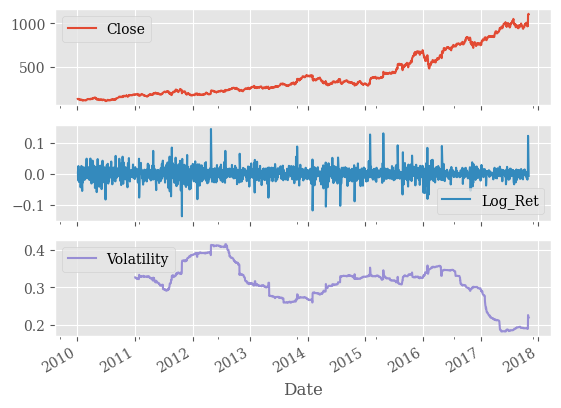

In [20]:
amzn.plot(subplots=True)

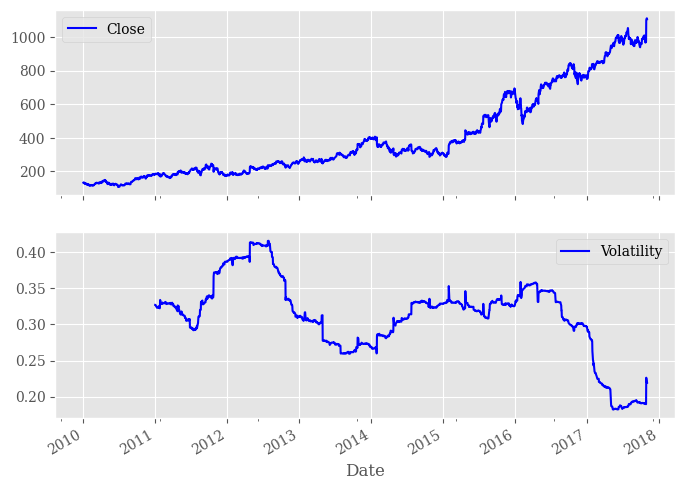

In [21]:
# %matplotlib inline
amzn[['Close', 'Volatility']].plot(subplots=True, color='blue',
                                   figsize=(8, 6), grid=True);
# tag: amzn_vola
# title: Amazon closing prices and yearly volatility

## Paradigm

In [22]:
loops = 2500000
from math import *
a = range(1, loops)
def f(x):
    return 3 * log(x) + cos(x) ** 2
%timeit r = [f(x) for x in a]

627 ms ± 7.54 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
import numpy as np
a = np.arange(1, loops)
%timeit r = 3 * np.log(a) + np.cos(a) ** 2

48.6 ms ± 348 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [24]:
import numexpr as ne
ne.set_num_threads(1)
f = '3 * log(a) + cos(a) ** 2'
%timeit r = ne.evaluate(f)

32.4 ms ± 754 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
ne.set_num_threads(4)
%timeit r = ne.evaluate(f)

11.6 ms ± 323 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>

**Quant Platform** |
<a href="http://quant-platform.com">http://quant-platform.com</a>

**Python for Finance** |
<a href="http://python-for-finance.com" target="_blank">Python for Finance @ O'Reilly</a>

**Derivatives Analytics with Python** |
<a href="http://derivatives-analytics-with-python.com" target="_blank">Derivatives Analytics @ Wiley Finance</a>

**Listed Volatility and Variance Derivatives** |
<a href="http://lvvd.tpq.io" target="_blank">Listed VV Derivatives @ Wiley Finance</a>

**Python Training** |
<a href="http://training.tpq.io" target="_blank">Python for Finance University Certificate</a>